In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("06-2023.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,35528246360,2023-06-01 08:59,Outbound,00:01:05,NaN,Ray Levesque
1,35528698026,2023-06-01 09:04,NaN,01:18:30,NaN,Vladimir Suparto
2,35533579563,2023-06-01 10:05,NaN,00:00:21,NaN,Cameron Dudley
3,35531066484,2023-06-01 10:05,NaN,00:41:24,NaN,Cameron Dudley
4,35530916141,2023-06-01 10:06,NaN,NaN,NaN,Cameron Dudley


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8745 entries, 0 to 8744
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             8745 non-null   int64  
 1   Activity date         8745 non-null   str    
 2   Call direction        349 non-null    str    
 3   Call duration         8103 non-null   str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  8745 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 716.9 KB


In [9]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [11]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors='coerce'
)

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 8745 entries, 0 to 8744
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         8745 non-null   datetime64[us]
 1   Call direction        349 non-null    str           
 2   Call duration         8103 non-null   str           
 3   Activity assigned to  8745 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 443.6 KB


# Call Count per day

In [16]:
df2 = df1.copy()

In [18]:
df2['date'] = df2['Activity date'].dt.date

In [20]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque,2023-06-01
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto,2023-06-01
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley,2023-06-01
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley,2023-06-01
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley,2023-06-01


In [22]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date' : 'date'})
)

In [24]:
daily_calls.head()

,date,call_count
0,2023-06-01,381
1,2023-06-02,365
2,2023-06-03,64
3,2023-06-04,8
4,2023-06-05,414


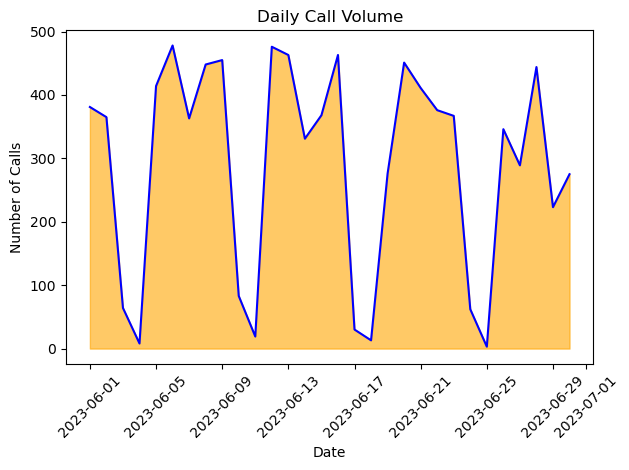

In [26]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color = 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [29]:
df1['day'] = df1['Activity date'].dt.day_name()

In [31]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque,Thursday
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto,Thursday
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley,Thursday
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley,Thursday
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley,Thursday


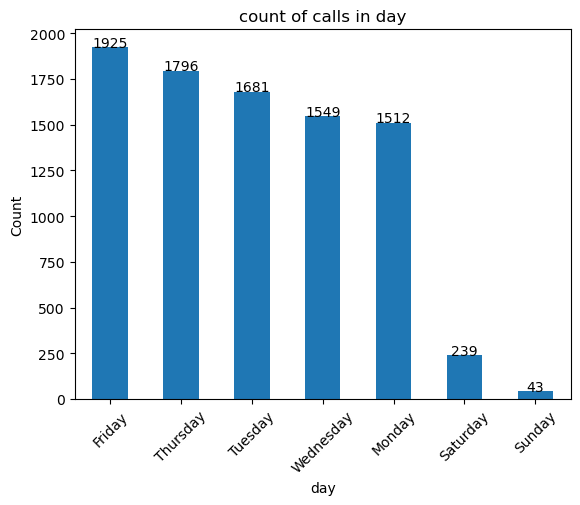

In [33]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

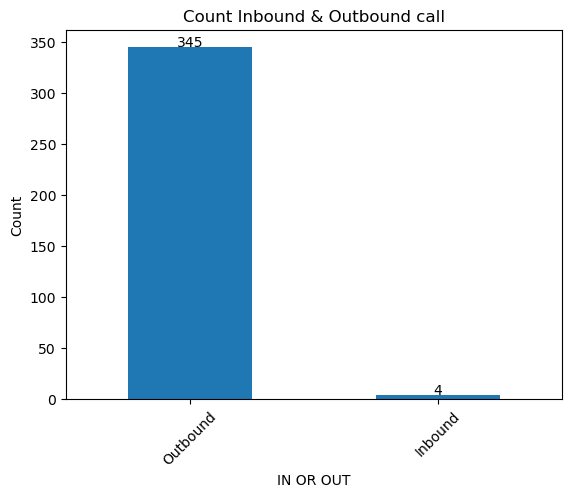

In [36]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [39]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

IndexError: index 0 is out of bounds for axis 0 with size 0

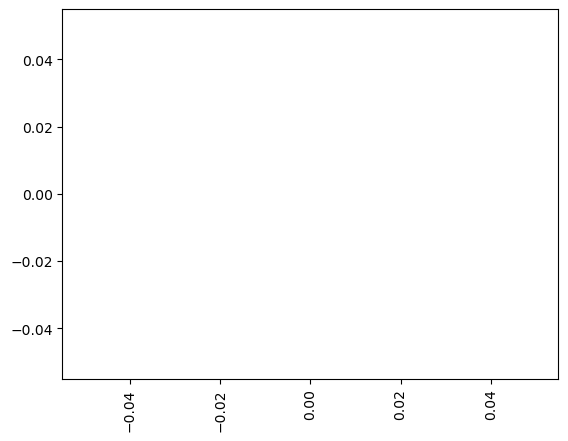

In [41]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call Duration NULL but have Call direction

In [44]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
167,2023-06-01 14:01:00,Outbound,NaN,Keith Antonio,Thursday
170,2023-06-01 14:03:00,Outbound,NaN,Keith Antonio,Thursday
269,2023-06-01 17:01:00,Outbound,NaN,Jinky Rance,Thursday
272,2023-06-01 17:04:00,Outbound,NaN,Jinky Rance,Thursday
273,2023-06-01 17:07:00,Outbound,NaN,Jinky Rance,Thursday
...,...,...,...,...,...
8023,2023-06-28 16:10:00,Outbound,NaN,Demmie Rose Tamonan,Wednesday
8058,2023-06-28 17:03:00,Outbound,NaN,Keith Antonio,Wednesday
8075,2023-06-28 17:50:00,Outbound,NaN,Keith Antonio,Wednesday
8339,2023-06-29 15:44:00,Outbound,NaN,Travis Fleming,Thursday


In [46]:
df4 = df1.copy()

In [48]:
df4.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2023-06-01 08:59:00,Outbound,00:01:05,Ray Levesque,Thursday
1,2023-06-01 09:04:00,NaN,01:18:30,Vladimir Suparto,Thursday
2,2023-06-01 10:05:00,NaN,00:00:21,Cameron Dudley,Thursday
3,2023-06-01 10:05:00,NaN,00:41:24,Cameron Dudley,Thursday
4,2023-06-01 10:06:00,NaN,NaN,Cameron Dudley,Thursday


In [50]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [52]:
(df4['Call duration'] == 0).sum()

0

In [54]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [56]:
df4 = df4.dropna(subset = ['Call direction'])

In [58]:
(df4['Call duration'] == 0).sum()

73

In [60]:
df4.info()

<class 'pandas.DataFrame'>
Index: 349 entries, 0 to 8733
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         349 non-null    datetime64[us]
 1   Call direction        349 non-null    str           
 2   Call duration         349 non-null    float64       
 3   Activity assigned to  349 non-null    str           
 4   day                   349 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 26.0 KB


# Working Call Assigner

In [63]:
df1['Activity assigned to'].nunique()

21

In [65]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[       'Ray Levesque',    'Vladimir Suparto',      'Cameron Dudley',
      'David Banister',         'Adrian Tran',          'Daniel Uli',
         'Jinky Rance',        'Andy Ramirez',        'David Valdez',
       'Tommie Walker',        'Karen Parker',       'Keith Antonio',
        'Dioni Canega',         'Paol Guzman',    'Benjamin Sklivas',
 'Demmie Rose Tamonan',        'Stephen Tarr',    'Chrystel Manabat',
      'Travis Fleming',         'Sal Berdayi',    'Kent Encarnacion']
Length: 21, dtype: str

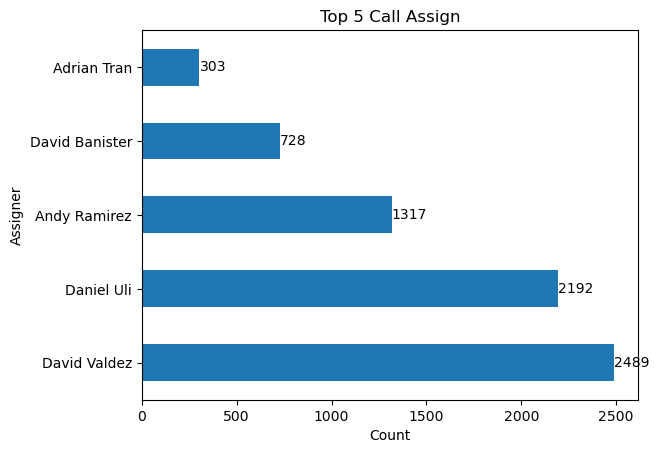

In [67]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [70]:
df4['Call duration'].max()

64.45

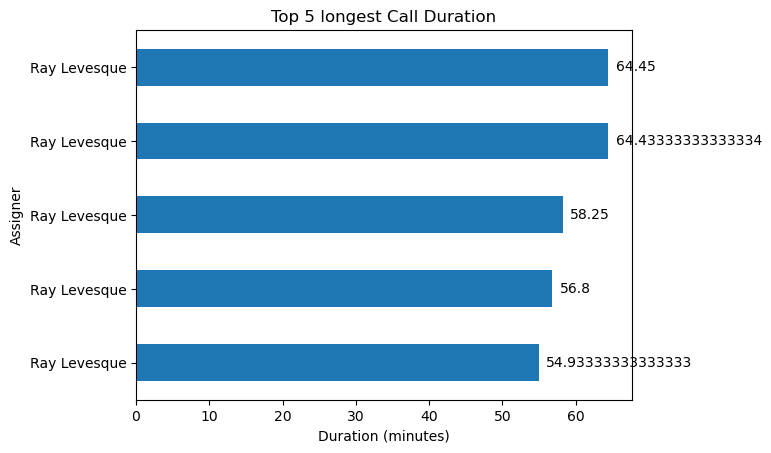

In [72]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# only Weekdays Call Volume

In [75]:
df3 = df1.copy()

In [77]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [79]:
df3['day'].unique()

<ArrowStringArray>
['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday']
Length: 5, dtype: str

In [81]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

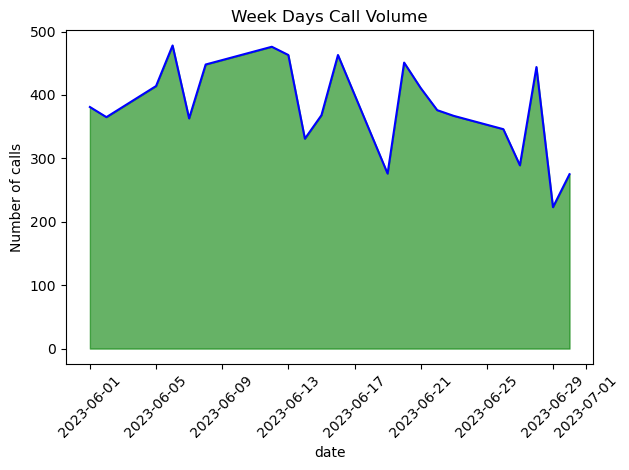

In [83]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [86]:
df5=df4.copy()

In [88]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [90]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
808,2023-06-03 15:40:00,Inbound,1.0,Ray Levesque,Saturday
3059,2023-06-11 11:09:00,Outbound,0.0,Keith Antonio,Sunday
3060,2023-06-11 11:12:00,Outbound,0.0,Keith Antonio,Sunday
3062,2023-06-11 12:03:00,Outbound,0.0,Keith Antonio,Sunday
3063,2023-06-11 12:10:00,Outbound,0.0,Keith Antonio,Sunday


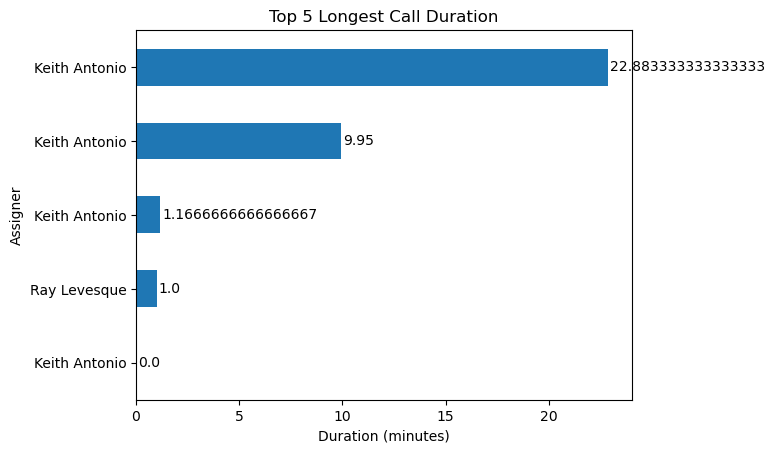

In [92]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

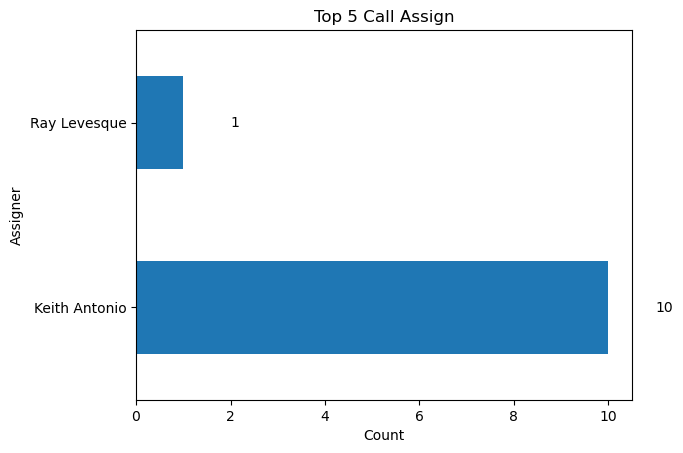

In [97]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [100]:
df4["Call duration"].mean()

5.215234001910219

In [102]:
df4["Call duration"].median()

0.8833333333333333

# Without Call Assigner Calls

In [105]:
df6 = df3.copy()

In [107]:
df6['month'] = df6['Activity date'].dt.month_name()

In [109]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

IndexError: index 0 is out of bounds for axis 0 with size 0

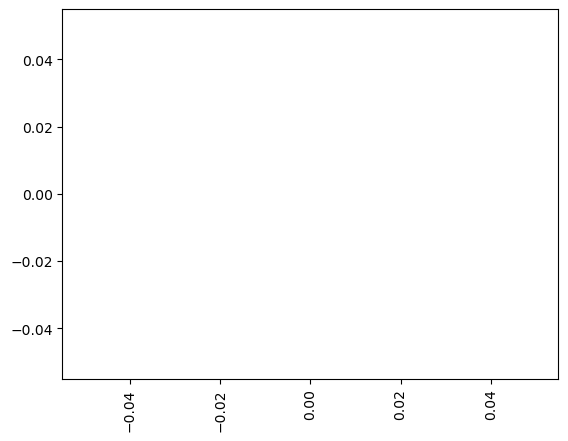

In [111]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [114]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [116]:
top5 = daily_calls.sort_values(ascending=False).head(5)

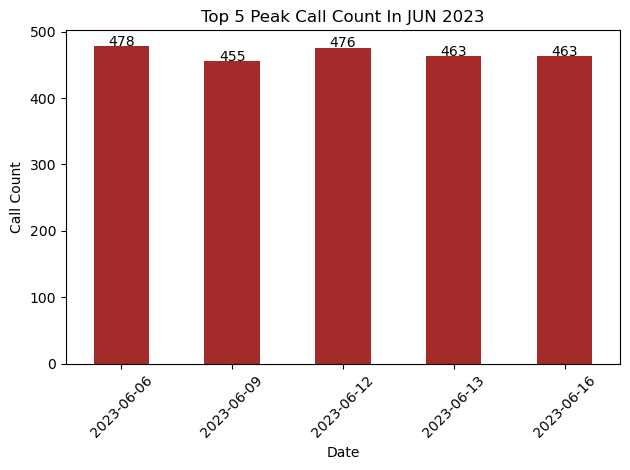

In [120]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In JUN 2023")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()